# Handling Imbalanced & Messy Real-World Data

In this task, I analyze an imbalanced classification problem using the
Credit Card Fraud Detection dataset. I will examine the class distribution,
visualize the imbalance, apply a balancing technique, and compare model
performance before and after handling the imbalance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

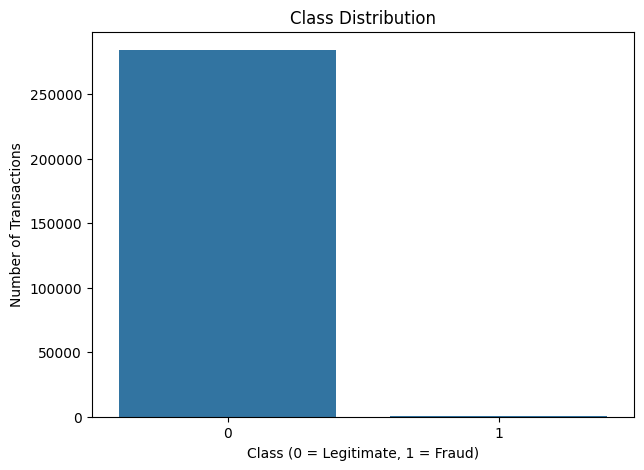

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

## Class Balance Observation

The target variable is highly imbalanced. Legitimate transactions
represent the vast majority of observations, while fraudulent transactions
are a very small minority.

This imbalance is important because a model could achieve high accuracy
by mostly predicting the majority class while still failing to identify
fraudulent transactions.

In [7]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 227845
Testing samples: 56962


## Feature Scaling

The numerical features have different ranges, so StandardScaler is used
to standardize the features before training Logistic Regression.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


## Baseline Logistic Regression

First, Logistic Regression is trained on the original imbalanced training
data. This provides a baseline for comparison before applying any
imbalance-handling technique.

In [10]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

y_pred_baseline = baseline_model.predict(
    X_test_scaled
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_precision = precision_score(
    y_test,
    y_pred_baseline
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline
)

print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1-Score:", baseline_f1)

Baseline Precision: 0.8266666666666667
Baseline Recall: 0.6326530612244898
Baseline F1-Score: 0.7167630057803468


In [12]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



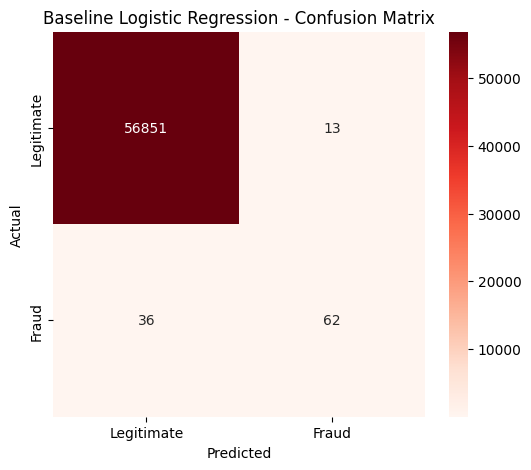

In [13]:
cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic
examples of the minority class instead of simply duplicating existing
fraud cases.

SMOTE is applied only to the training data. The test data remains
unchanged so that evaluation represents the original real-world
distribution.

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


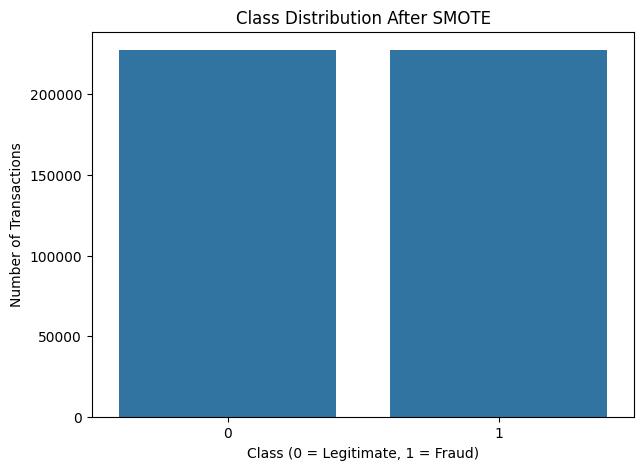

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_smote
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

### SMOTE Observation

Before SMOTE, fraudulent transactions were much fewer than legitimate
transactions. After applying SMOTE to the training data, the minority
fraud class was increased using synthetic samples, resulting in a
balanced training dataset.

In [16]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = smote_model.predict(
    X_test_scaled
)

print("SMOTE model trained successfully.")

SMOTE model trained successfully.


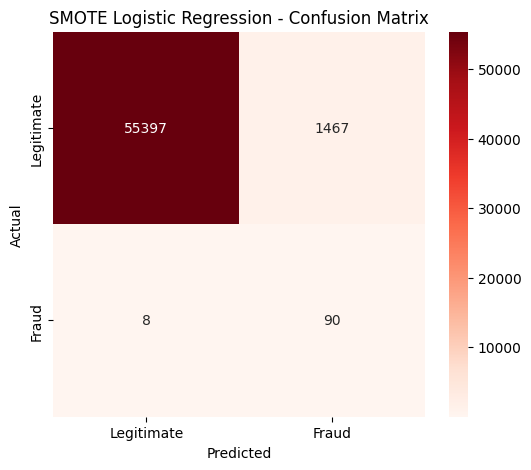

In [22]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("SMOTE Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
smote_precision = precision_score(
    y_test,
    y_pred_smote
)

smote_recall = recall_score(
    y_test,
    y_pred_smote
)

smote_f1 = f1_score(
    y_test,
    y_pred_smote
)

print("SMOTE Precision:", smote_precision)
print("SMOTE Recall:", smote_recall)
print("SMOTE F1-Score:", smote_f1)

SMOTE Precision: 0.057803468208092484
SMOTE Recall: 0.9183673469387755
SMOTE F1-Score: 0.10876132930513595


In [18]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Logistic Regression + SMOTE"
    ],
    "Precision": [
        baseline_precision,
        smote_precision
    ],
    "Recall": [
        baseline_recall,
        smote_recall
    ],
    "F1-Score": [
        baseline_f1,
        smote_f1
    ]
})

comparison

,Model,Precision,Recall,F1-Score
0,Baseline Logistic Regression,0.826667,0.632653,0.716763
1,Logistic Regression + SMOTE,0.057803,0.918367,0.108761


In [20]:
comparison_rounded = comparison.copy()

comparison_rounded[
    ["Precision", "Recall", "F1-Score"]
] = (
    comparison_rounded[
        ["Precision", "Recall", "F1-Score"]
    ] * 100
).round(2)

comparison_rounded

,Model,Precision,Recall,F1-Score
0,Baseline Logistic Regression,82.67,63.27,71.68
1,Logistic Regression + SMOTE,5.78,91.84,10.88


### Performance Observation

The baseline Logistic Regression model achieved 82.67% precision,
63.27% recall, and 71.68% F1-score.

After applying SMOTE, recall increased substantially from 63.27% to
91.84%, meaning the model detected a much larger proportion of fraudulent
transactions.

However, precision dropped from 82.67% to 5.78%, which means the SMOTE
model classified many legitimate transactions as fraud.

As a result, the F1-score decreased from 71.68% to 10.88%. This shows
that handling class imbalance can improve minority-class recall while
also introducing a significant precision trade-off.

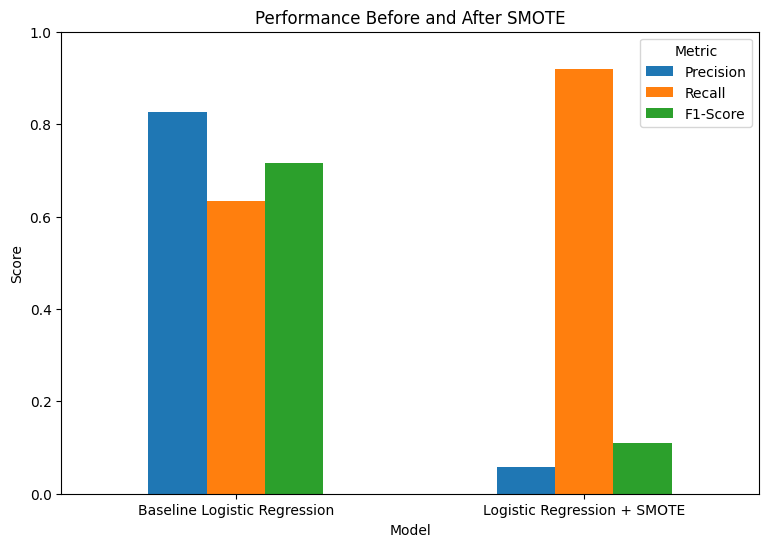

In [21]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Performance Before and After SMOTE")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()

## Why Accuracy Is Misleading for Fraud Detection

Accuracy can be misleading for highly imbalanced datasets because the
majority class dominates the total number of observations. A model could
predict almost every transaction as legitimate and still achieve very high
accuracy while failing to detect fraudulent transactions. For fraud
detection, Precision, Recall, and F1-Score are more informative because
they focus on the model's ability to identify the minority fraud class.
Recall is particularly important when missing a fraudulent transaction
can have a significant cost.

## Final Conclusion

The Credit Card Fraud Detection dataset is highly imbalanced, making
accuracy alone an unreliable measure of model performance.

The baseline Logistic Regression model achieved a precision of 82.67%,
recall of 63.27%, and F1-score of 71.68%.

After applying SMOTE, recall increased significantly to 91.84%, but
precision decreased to 5.78%, resulting in an F1-score of 10.88%.

This experiment demonstrates that there is a trade-off between detecting
more fraudulent transactions and avoiding false fraud alerts. Therefore,
the appropriate evaluation metric depends on the business cost of missed
fraud versus false alerts.